# ⏰ Time Series Analysis: Musk Tweets & Crypto Prices

## Temporal Dynamics & Granger Causality

---

This notebook examines the **temporal relationship** between Elon Musk's tweet metrics (sentiment, volume) and cryptocurrency price movements using time series methods.

### Key Questions:
1. **Granger Causality**: Do tweet metrics predict future price changes?
2. **Temporal Patterns**: How do sentiment and engagement evolve over time?
3. **Lead-Lag Relationships**: What's the optimal time lag between tweets and price impact?

### Methodology:
- Aggregate event-based data into daily time series
- Test for stationarity (ADF test)
- Granger causality testing
- Rolling correlation analysis

**Note**: Price data is local to each tweet (±1h, ±24h, ±7d), not continuous time series.

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

In [3]:
df = pd.read_csv('../data/curated/musk_crypto_tweets_final.csv')
df.columns

Index(['id', 'fullText', 'retweetCount', 'replyCount', 'likeCount',
       'quoteCount', 'viewCount', 'createdAt', 'isReply', 'bookmarkCount',
       'inReplyToUsername', 'isRetweet', 'isQuote', 'possiblySensitive',
       'quoted_text', 'quoted_author', 'quoted_author_followers',
       'combined_text', 'tweet_type', 'engagement_rate', 'virality_ratio',
       'conversation_ratio', 'hour_utc', 'day_of_week', 'is_us_market_hours',
       'is_crypto_related', 'sentiment', 'sentiment_score', 'matched_keywords',
       'crypto_tokens', 'event_type', 'has_market_signal', 'market_signal',
       'stance_on_original', 'price_token', 'price_before_24h',
       'price_before_1h', 'price_at_tweet', 'price_after_1h',
       'price_after_24h', 'price_after_7d', 'volume_at_tweet', 'pct_change_1h',
       'pct_change_24h', 'pct_change_7d'],
      dtype='object')

In [2]:
# Load data
df = pd.read_csv('../data/curated/musk_crypto_tweets_final.csv')
df['createdAt'] = pd.to_datetime(df['createdAt'])
df['date'] = df['createdAt'].dt.date

# Focus on DOGE (94.6% of data) and tweets with price data
df_doge = df[(df['price_token'] == 'DOGE') & (df['price_at_tweet'].notna())].copy()

print(f"Total DOGE tweets with price data: {len(df_doge):,}")
print(f"Date range: {df_doge['createdAt'].min().date()} to {df_doge['createdAt'].max().date()}")
print(f"Tweet types: {df_doge['tweet_type'].value_counts().to_dict()}")

Total DOGE tweets with price data: 944
Date range: 2016-03-31 to 2025-04-13
Tweet types: {'quote': 488, 'reply': 286, 'original': 97, 'retweet': 73}


## 2. Create Daily Time Series

Aggregate event-based data into daily metrics:
- **Tweet volume**: Number of tweets per day
- **Average sentiment**: Mean sentiment score
- **Engagement**: Mean likes/retweets
- **Price change**: Mean 24h price change

**Important**: Since price data is local to each tweet (not continuous), we use the mean of all tweets' price changes on that day.

In [3]:
# Aggregate to daily level
daily = df_doge.groupby('date').agg({
    'id': 'count',  # tweet count
    'sentiment_score': 'mean',
    'likeCount': 'mean',
    'retweetCount': 'mean',
    'pct_change_1h': 'mean',
    'pct_change_24h': 'mean',
    'pct_change_7d': 'mean',
    'engagement_rate': 'mean',
    'has_market_signal': 'sum'  # count of tweets with market signals
}).rename(columns={'id': 'tweet_count'})

# Convert to proper datetime index for time series
daily.index = pd.to_datetime(daily.index)
daily = daily.sort_index()

# Focus on 2020-2025 (main activity period)
daily = daily['2020':'2025']

print(f"Daily time series length: {len(daily)} days")
print(f"\nDaily statistics:")
print(daily.describe().round(3))

Daily time series length: 309 days

Daily statistics:
       tweet_count  sentiment_score    likeCount  retweetCount  pct_change_1h  \
count      309.000          309.000      309.000       309.000        309.000   
mean         2.867            0.353   106188.803     14575.198         -0.012   
std          3.663            0.345   170340.402     22824.111          0.402   
min          1.000           -0.800        0.000        43.000         -5.625   
25%          1.000            0.000    21941.000      2566.500          0.000   
50%          1.000            0.400    66050.000     10016.000          0.000   
75%          3.000            0.633   132284.000     19147.400          0.000   
max         24.000            0.900  2391541.000    311782.000          3.821   

       pct_change_24h  pct_change_7d  engagement_rate  has_market_signal  
count         309.000        309.000          204.000            309.000  
mean           -0.209          0.373            0.084             

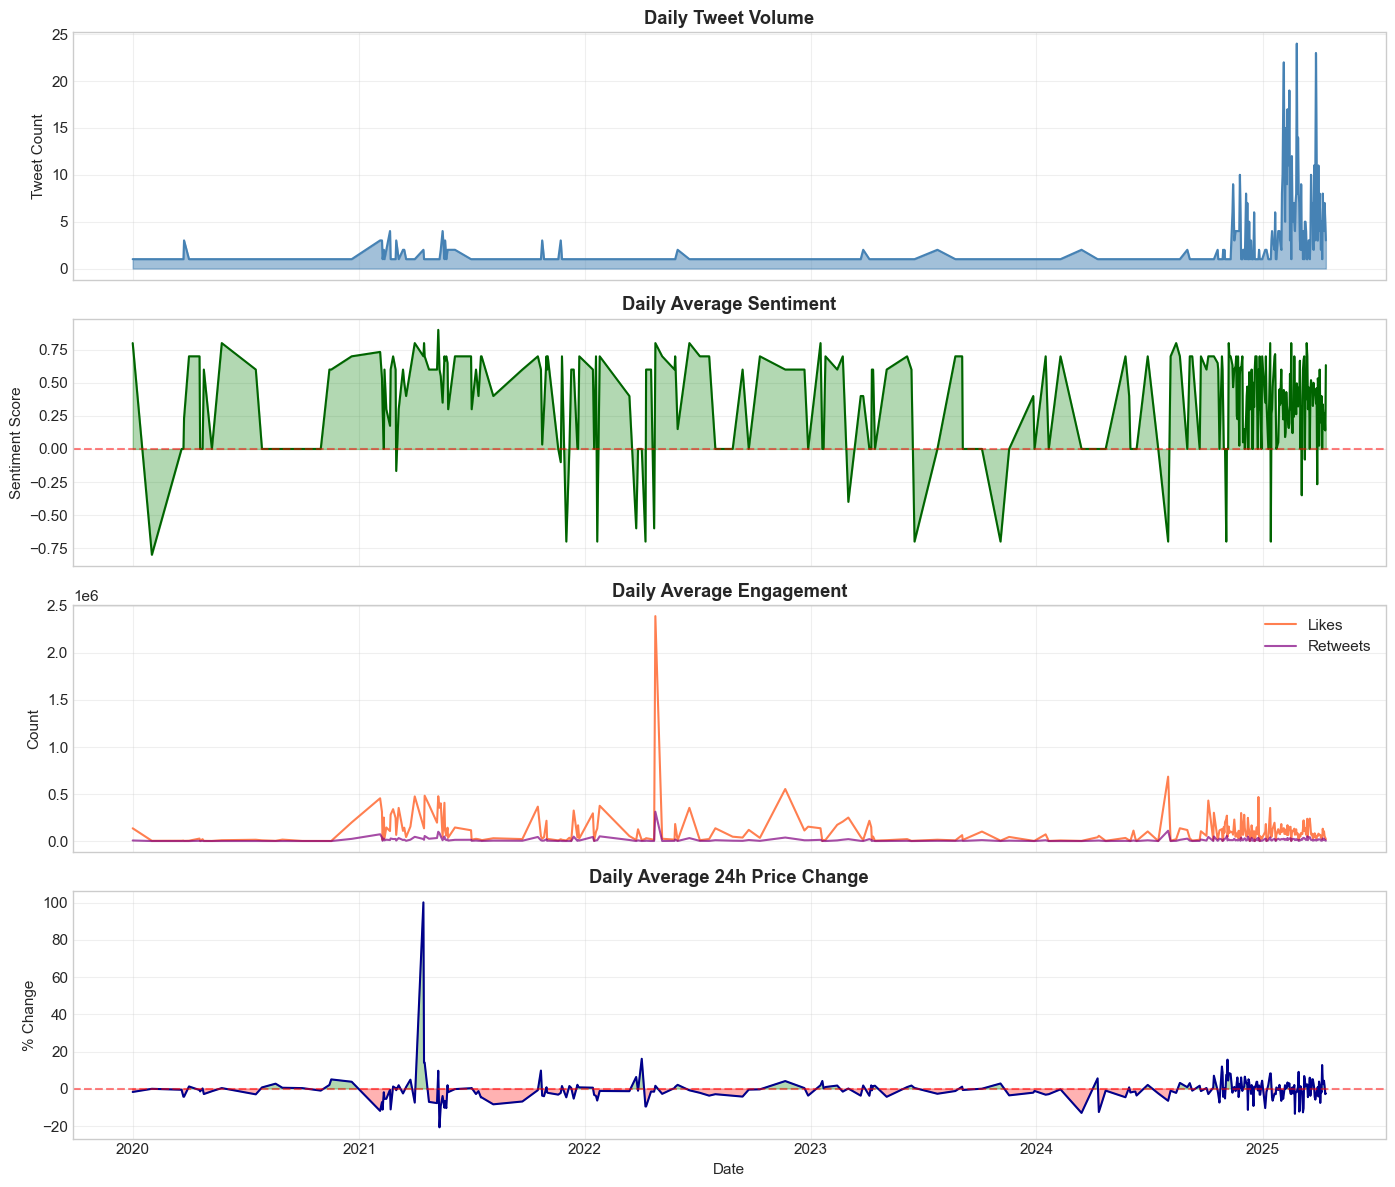

In [4]:
# Visualize daily time series
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Tweet volume
axes[0].fill_between(daily.index, daily['tweet_count'], alpha=0.5, color='steelblue')
axes[0].plot(daily.index, daily['tweet_count'], color='steelblue', linewidth=1.5)
axes[0].set_ylabel('Tweet Count')
axes[0].set_title('Daily Tweet Volume', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Average sentiment
axes[1].plot(daily.index, daily['sentiment_score'], color='darkgreen', linewidth=1.5)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].fill_between(daily.index, daily['sentiment_score'], alpha=0.3, color='green')
axes[1].set_ylabel('Sentiment Score')
axes[1].set_title('Daily Average Sentiment', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Engagement
axes[2].plot(daily.index, daily['likeCount'], color='coral', linewidth=1.5, label='Likes')
axes[2].plot(daily.index, daily['retweetCount'], color='purple', linewidth=1.5, alpha=0.7, label='Retweets')
axes[2].set_ylabel('Count')
axes[2].set_title('Daily Average Engagement', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Price change
axes[3].plot(daily.index, daily['pct_change_24h'], color='darkblue', linewidth=1.5)
axes[3].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[3].fill_between(daily.index, daily['pct_change_24h'], alpha=0.3, 
                     where=(daily['pct_change_24h'] >= 0), color='green', interpolate=True)
axes[3].fill_between(daily.index, daily['pct_change_24h'], alpha=0.3,
                     where=(daily['pct_change_24h'] < 0), color='red', interpolate=True)
axes[3].set_ylabel('% Change')
axes[3].set_xlabel('Date')
axes[3].set_title('Daily Average 24h Price Change', fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/11_daily_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Stationarity Testing (ADF Test)

Before Granger causality testing, we need to check if time series are stationary.

**ADF Test**:
- H0: Time series has unit root (non-stationary)
- H1: Time series is stationary
- p < 0.05 → Reject H0 → Stationary

In [5]:
def adf_test(series, name):
    """Perform Augmented Dickey-Fuller test"""
    series_clean = series.dropna()
    result = adfuller(series_clean, autolag='AIC')
    
    print(f"\n{name}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Critical Values: {result[4]}")
    
    if result[1] < 0.05:
        print(f"  ✓ STATIONARY (p < 0.05)")
        return True
    else:
        print(f"  ✗ NON-STATIONARY (p >= 0.05)")
        return False

print("="*60)
print("STATIONARITY TESTS (Augmented Dickey-Fuller)")
print("="*60)

# Test key variables
adf_test(daily['tweet_count'], 'Tweet Count')
adf_test(daily['sentiment_score'], 'Sentiment Score')
adf_test(daily['likeCount'], 'Like Count')
adf_test(daily['pct_change_24h'], '24h Price Change')

STATIONARITY TESTS (Augmented Dickey-Fuller)

Tweet Count:
  ADF Statistic: -2.7075
  p-value: 0.0728
  Critical Values: {'1%': -3.4521902441030963, '5%': -2.871158406898617, '10%': -2.5718948388228586}
  ✗ NON-STATIONARY (p >= 0.05)

Sentiment Score:
  ADF Statistic: -8.7837
  p-value: 0.0000
  Critical Values: {'1%': -3.4519023023726696, '5%': -2.8710320399170537, '10%': -2.57182745012602}
  ✓ STATIONARY (p < 0.05)

Like Count:
  ADF Statistic: -17.0332
  p-value: 0.0000
  Critical Values: {'1%': -3.45176116018037, '5%': -2.870970093607691, '10%': -2.571794416006072}
  ✓ STATIONARY (p < 0.05)

24h Price Change:
  ADF Statistic: -10.3034
  p-value: 0.0000
  Critical Values: {'1%': -3.4518314994261337, '5%': -2.8710009653519166, '10%': -2.571810878948318}
  ✓ STATIONARY (p < 0.05)


True

## 4. Granger Causality Tests

**Question**: Do tweet metrics (sentiment, volume) Granger-cause price changes?

**Granger Causality**:
- Tests if past values of X help predict future values of Y
- H0: X does NOT Granger-cause Y
- p < 0.05 → X Granger-causes Y

**Note**: Granger causality doesn't imply true causality, only predictive power.

We test multiple lags (1-7 days) to find optimal predictive window.

In [6]:
# Prepare data for Granger tests (fill missing days with 0 tweets, forward-fill others)
# Create complete date range
date_range = pd.date_range(start=daily.index.min(), end=daily.index.max(), freq='D')
daily_complete = daily.reindex(date_range)

# Fill missing tweet counts with 0 (no tweets that day)
daily_complete['tweet_count'] = daily_complete['tweet_count'].fillna(0)

# For other metrics, forward fill (use last known value)
daily_complete['sentiment_score'] = daily_complete['sentiment_score'].fillna(method='ffill')
daily_complete['pct_change_24h'] = daily_complete['pct_change_24h'].fillna(0)
daily_complete['likeCount'] = daily_complete['likeCount'].fillna(method='ffill')

print(f"Complete daily time series: {len(daily_complete)} days")
print(f"Missing values: {daily_complete.isna().sum().sum()}")

Complete daily time series: 1930 days
Missing values: 8210


In [7]:
def granger_test_summary(data, x_col, y_col, max_lag=7):
    """
    Perform Granger causality test for multiple lags
    Tests: Does x_col Granger-cause y_col?
    """
    print(f"\n{'='*60}")
    print(f"Does '{x_col}' Granger-cause '{y_col}'?")
    print(f"{'='*60}")
    
    # Prepare data
    df_test = data[[y_col, x_col]].dropna()
    
    if len(df_test) < 30:
        print("Insufficient data for Granger test")
        return
    
    try:
        # Run Granger test
        result = grangercausalitytests(df_test, max_lag, verbose=False)
        
        # Extract p-values for each lag
        print(f"\n{'Lag':<6} {'F-stat':<12} {'p-value':<12} {'Significant?':<15}")
        print("-" * 50)
        
        min_p = 1.0
        best_lag = None
        
        for lag in range(1, max_lag + 1):
            f_stat = result[lag][0]['ssr_ftest'][0]
            p_value = result[lag][0]['ssr_ftest'][1]
            
            if p_value < min_p:
                min_p = p_value
                best_lag = lag
            
            sig = "✓ YES" if p_value < 0.05 else "✗ No"
            stars = "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.1 else ""
            
            print(f"{lag:<6} {f_stat:<12.4f} {p_value:<12.4f} {sig:<15} {stars}")
        
        print(f"\nBest lag: {best_lag} days (p = {min_p:.4f})")
        
        if min_p < 0.05:
            print(f"✓ CONCLUSION: '{x_col}' DOES Granger-cause '{y_col}'")
        else:
            print(f"✗ CONCLUSION: '{x_col}' does NOT Granger-cause '{y_col}'")
            
    except Exception as e:
        print(f"Error in Granger test: {e}")

In [8]:
# Test 1: Does tweet volume Granger-cause price changes?
granger_test_summary(daily_complete, 'tweet_count', 'pct_change_24h', max_lag=7)


Does 'tweet_count' Granger-cause 'pct_change_24h'?

Lag    F-stat       p-value      Significant?   
--------------------------------------------------
1      0.3645       0.5461       ✗ No            
2      0.1890       0.8278       ✗ No            
3      0.4309       0.7309       ✗ No            
4      0.6200       0.6483       ✗ No            
5      0.5013       0.7755       ✗ No            
6      0.7883       0.5790       ✗ No            
7      0.8219       0.5690       ✗ No            

Best lag: 1 days (p = 0.5461)
✗ CONCLUSION: 'tweet_count' does NOT Granger-cause 'pct_change_24h'


In [9]:
# Test 2: Does sentiment Granger-cause price changes?
granger_test_summary(daily_complete, 'sentiment_score', 'pct_change_24h', max_lag=7)


Does 'sentiment_score' Granger-cause 'pct_change_24h'?

Lag    F-stat       p-value      Significant?   
--------------------------------------------------
1      0.0082       0.9277       ✗ No            
2      0.0188       0.9814       ✗ No            
3      0.0126       0.9981       ✗ No            
4      0.0207       0.9992       ✗ No            
5      0.1565       0.9781       ✗ No            
6      0.1365       0.9915       ✗ No            
7      0.1489       0.9941       ✗ No            

Best lag: 1 days (p = 0.9277)
✗ CONCLUSION: 'sentiment_score' does NOT Granger-cause 'pct_change_24h'


In [10]:
# Test 3: Does engagement (likes) Granger-cause price changes?
granger_test_summary(daily_complete, 'likeCount', 'pct_change_24h', max_lag=7)


Does 'likeCount' Granger-cause 'pct_change_24h'?

Lag    F-stat       p-value      Significant?   
--------------------------------------------------
1      1.0950       0.2955       ✗ No            
2      0.5520       0.5759       ✗ No            
3      0.4808       0.6956       ✗ No            
4      0.3826       0.8212       ✗ No            
5      0.3097       0.9073       ✗ No            
6      0.2688       0.9516       ✗ No            
7      0.3447       0.9334       ✗ No            

Best lag: 1 days (p = 0.2955)
✗ CONCLUSION: 'likeCount' does NOT Granger-cause 'pct_change_24h'


In [11]:
# Reverse test: Does price change Granger-cause tweet volume?
granger_test_summary(daily_complete, 'pct_change_24h', 'tweet_count', max_lag=7)


Does 'pct_change_24h' Granger-cause 'tweet_count'?

Lag    F-stat       p-value      Significant?   
--------------------------------------------------
1      0.1218       0.7272       ✗ No            
2      0.0631       0.9389       ✗ No            
3      0.9708       0.4056       ✗ No            
4      1.6661       0.1552       ✗ No            
5      1.4926       0.1890       ✗ No            
6      1.3971       0.2120       ✗ No            
7      1.3873       0.2063       ✗ No            

Best lag: 4 days (p = 0.1552)
✗ CONCLUSION: 'pct_change_24h' does NOT Granger-cause 'tweet_count'


## 5. Rolling Correlation Analysis

Examine how the relationship between tweet metrics and price changes evolves over time.

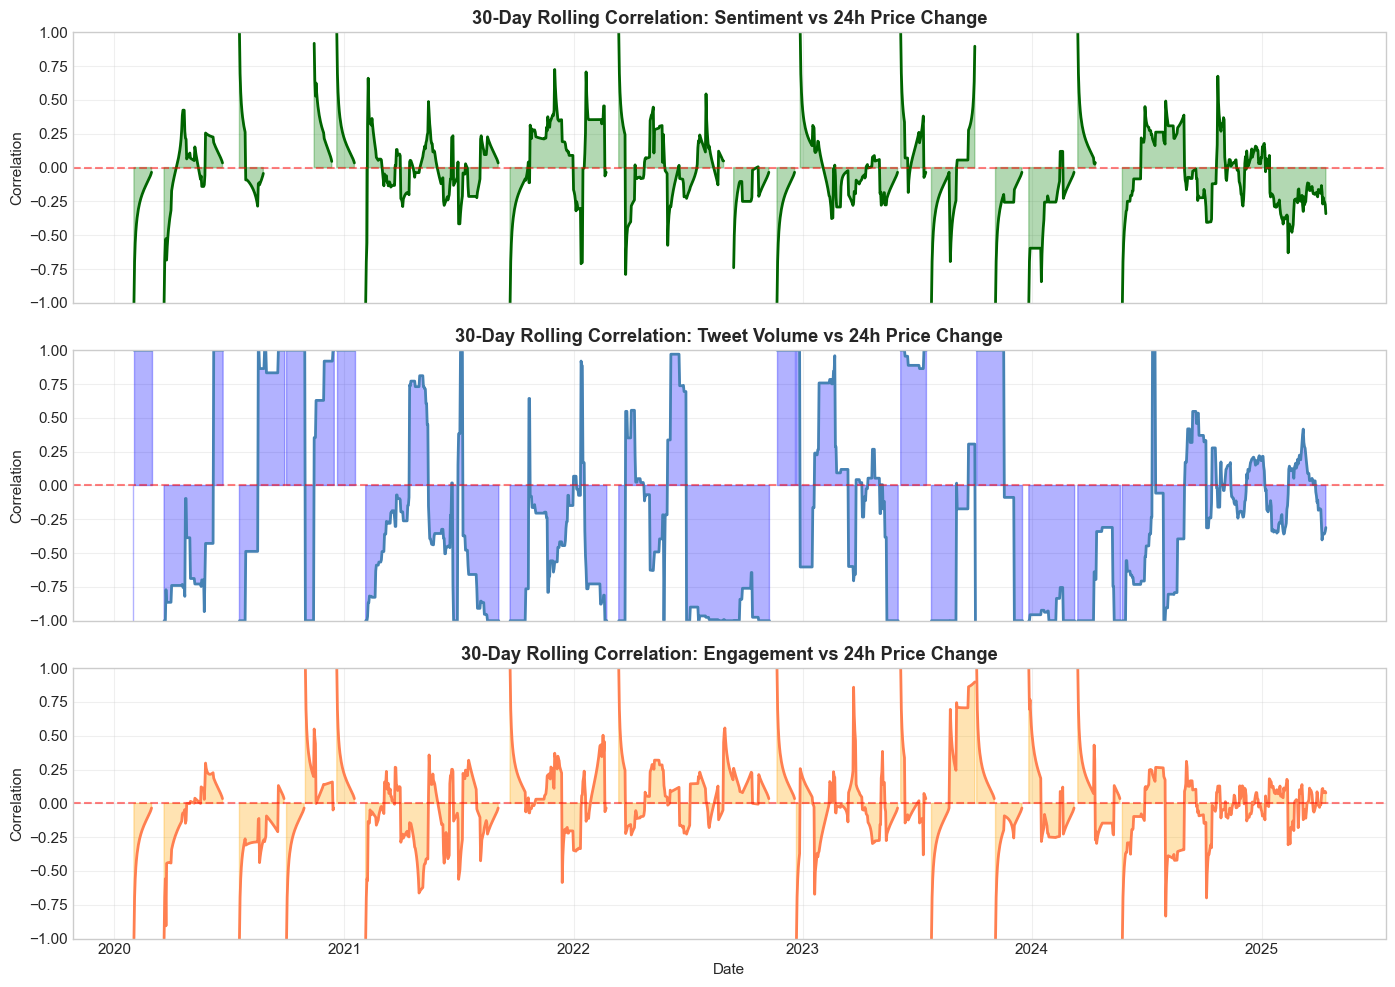

In [12]:
# Calculate rolling correlations (30-day window)
window = 30

rolling_corr_sentiment = daily_complete['sentiment_score'].rolling(window).corr(daily_complete['pct_change_24h'])
rolling_corr_volume = daily_complete['tweet_count'].rolling(window).corr(daily_complete['pct_change_24h'])
rolling_corr_engagement = daily_complete['likeCount'].rolling(window).corr(daily_complete['pct_change_24h'])

# Plot rolling correlations
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(daily_complete.index, rolling_corr_sentiment, color='darkgreen', linewidth=2)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].fill_between(daily_complete.index, rolling_corr_sentiment, alpha=0.3, color='green')
axes[0].set_ylabel('Correlation')
axes[0].set_title(f'{window}-Day Rolling Correlation: Sentiment vs 24h Price Change', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1, 1)

axes[1].plot(daily_complete.index, rolling_corr_volume, color='steelblue', linewidth=2)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].fill_between(daily_complete.index, rolling_corr_volume, alpha=0.3, color='blue')
axes[1].set_ylabel('Correlation')
axes[1].set_title(f'{window}-Day Rolling Correlation: Tweet Volume vs 24h Price Change', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1, 1)

axes[2].plot(daily_complete.index, rolling_corr_engagement, color='coral', linewidth=2)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].fill_between(daily_complete.index, rolling_corr_engagement, alpha=0.3, color='orange')
axes[2].set_ylabel('Correlation')
axes[2].set_xlabel('Date')
axes[2].set_title(f'{window}-Day Rolling Correlation: Engagement vs 24h Price Change', fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-1, 1)

plt.tight_layout()
plt.savefig('../reports/figures/12_rolling_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Lead-Lag Analysis

Test correlations at different time lags to identify optimal predictive window.

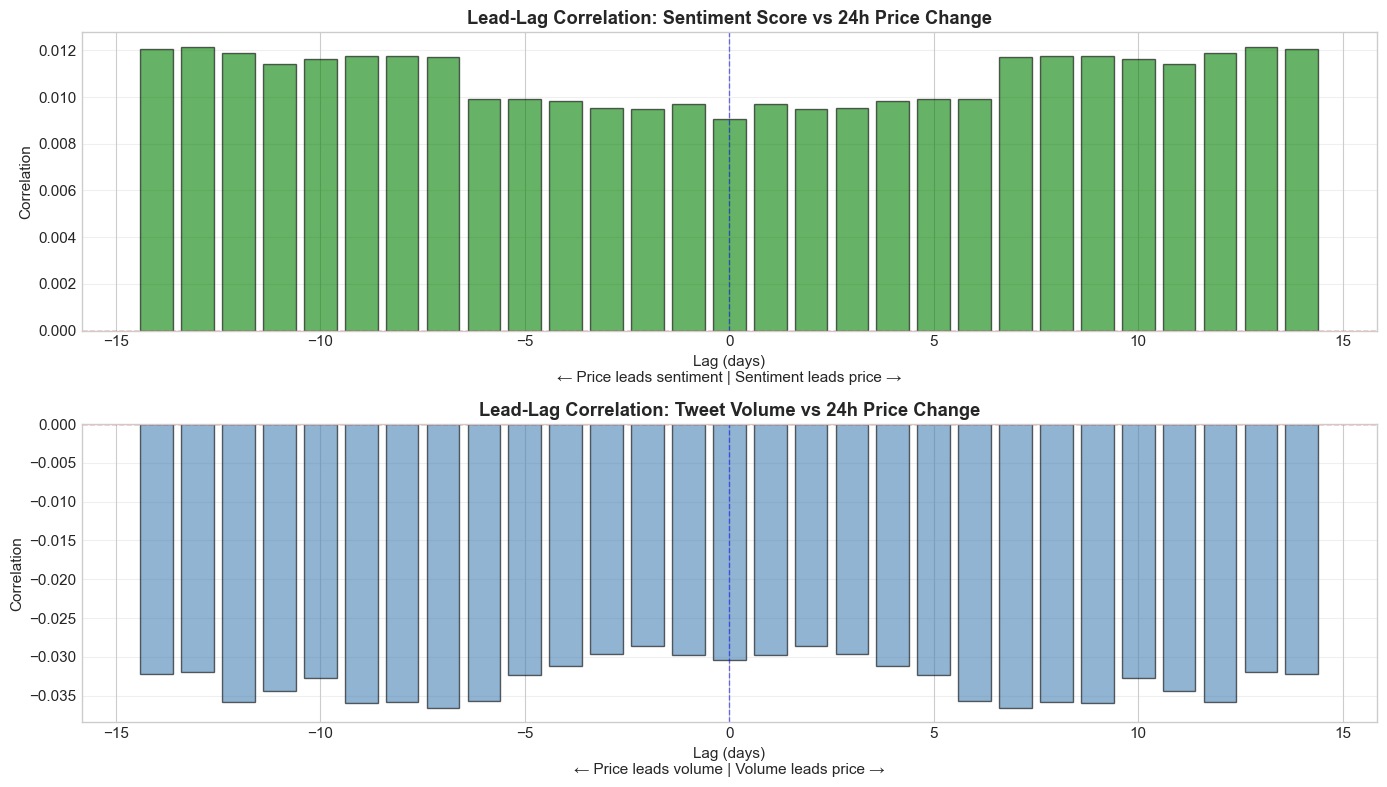


Optimal lag for sentiment: -13 days (correlation: 0.012)
Optimal lag for volume: -7 days (correlation: -0.037)


In [13]:
def compute_lead_lag_correlation(x, y, max_lag=14):
    """
    Compute correlation between x and y at different lags
    Positive lag: x leads y (x at t, y at t+lag)
    Negative lag: y leads x (x at t+lag, y at t)
    """
    lags = range(-max_lag, max_lag + 1)
    correlations = []
    
    for lag in lags:
        if lag < 0:
            # y leads x
            corr = x.iloc[-lag:].corr(y.iloc[:lag])
        elif lag > 0:
            # x leads y
            corr = x.iloc[:-lag].corr(y.iloc[lag:])
        else:
            # No lag
            corr = x.corr(y)
        
        correlations.append(corr)
    
    return list(lags), correlations

# Compute lead-lag correlations
lags_sent, corr_sent = compute_lead_lag_correlation(
    daily_complete['sentiment_score'], 
    daily_complete['pct_change_24h'], 
    max_lag=14
)

lags_vol, corr_vol = compute_lead_lag_correlation(
    daily_complete['tweet_count'], 
    daily_complete['pct_change_24h'], 
    max_lag=14
)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(lags_sent, corr_sent, color='green', alpha=0.6, edgecolor='black')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].axvline(x=0, color='blue', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_ylabel('Correlation')
axes[0].set_title('Lead-Lag Correlation: Sentiment Score vs 24h Price Change', fontweight='bold')
axes[0].set_xlabel('Lag (days)\n← Price leads sentiment | Sentiment leads price →')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(lags_vol, corr_vol, color='steelblue', alpha=0.6, edgecolor='black')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].axvline(x=0, color='blue', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_ylabel('Correlation')
axes[1].set_title('Lead-Lag Correlation: Tweet Volume vs 24h Price Change', fontweight='bold')
axes[1].set_xlabel('Lag (days)\n← Price leads volume | Volume leads price →')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/figures/13_lead_lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Find optimal lags
max_corr_sent = max(corr_sent, key=abs)
optimal_lag_sent = lags_sent[corr_sent.index(max_corr_sent)]

max_corr_vol = max(corr_vol, key=abs)
optimal_lag_vol = lags_vol[corr_vol.index(max_corr_vol)]

print(f"\nOptimal lag for sentiment: {optimal_lag_sent} days (correlation: {max_corr_sent:.3f})")
print(f"Optimal lag for volume: {optimal_lag_vol} days (correlation: {max_corr_vol:.3f})")